# Principal Component Analysis (PCA) on the MNIST Dataset

## Objective
This notebook presents **Principal Component Analysis (PCA)** on MNIST in a clear and self-contained way. The goal is to reduce the dimensionality of handwritten digit images while preserving as much information as possible.

## Why PCA?
- MNIST has 784 features per image (28×28 pixels).
- PCA finds orthogonal directions that preserve the largest amount of variance.
- It is an **unsupervised** method, so the projection does not use class labels.

## What we will do
1. Configure a local data cache.
2. Load MNIST once and reuse the cached files on future runs.
3. Normalize the images.
4. Apply PCA and study explained variance.
5. Visualize the compressed space.
6. Compare classification performance before and after PCA.

## Main idea
PCA solves an eigenvalue problem on the covariance matrix and returns axes ordered by importance. The first components keep the most information, and later ones keep progressively less.


---
## STEP 1: Import Essential Libraries

In [1]:
# ============================================================================
# MAIN IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ============================================================================
# PATH CONFIGURATION - PROJECT ORGANIZATION
# ============================================================================
# Local structure:
#   ./data/         ← Persistent datasets and cache for notebook execution
#   ./notebooks/    ← Jupyter notebooks
# ============================================================================

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CACHE_DIR = DATA_DIR / 'cache'
DATASETS_DIR = DATA_DIR / 'datasets'
MNIST_CACHE_DIR = CACHE_DIR / 'openml'

DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
MNIST_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('\n✅ Paths initialized successfully!')


✅ Paths initialized successfully!


### Why a full dataset?
PCA is meant to show how the data compresses when all the available structure is kept. Here we use the full MNIST dataset so the compression is based on the complete distribution of handwritten digits, not on a small subset.


In [3]:
# ============================================================================
# LOAD FULL MNIST FROM OPENML WITH LOCAL CACHE
# ============================================================================
# Strategy:
#   1. Reuse the local cache in ./data/cache so the dataset is not downloaded again
#   2. Convert labels to integers
#   3. Use the full MNIST base: 70,000 images
# ============================================================================

print('📥 Loading full MNIST from OpenML with local cache...')


cache_hits = list(MNIST_CACHE_DIR.glob('**/*mnist*'))
if cache_hits:
    print(f'   - Existing cached MNIST files found: {len(cache_hits)}')
else:
    print('   - No cached MNIST files found yet; OpenML will download once and reuse them later')

X_full, y_full = fetch_openml(
    'mnist_784',
    version=1,
    return_X_y=True,
    as_frame=False,
    parser='auto',
    data_home=str(CACHE_DIR),
)
y_full = y_full.astype(int)

# Use the complete MNIST dataset for training and evaluation
X = X_full
y = y_full

print('✅ Full MNIST loaded successfully')
print(f'\n📊 Dataset dimensions:')
print(f'   - Number of images: {X.shape[0]}')
print(f'   - Number of features: {X.shape[1]} (28×28 = 784 pixels)')
print(f'   - Number of classes: {len(np.unique(y))} (digits 0-9)')
print(f'   - Class distribution: {np.bincount(y)}')
print('\n✅ Dataset ready for preprocessing!')

📥 Loading full MNIST from OpenML with local cache...
   - Existing cached MNIST files found: 1
✅ Full MNIST loaded successfully

📊 Dataset dimensions:
   - Number of images: 70000
   - Number of features: 784 (28×28 = 784 pixels)
   - Number of classes: 10 (digits 0-9)
   - Class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]

✅ Dataset ready for preprocessing!


### Why a full dataset?
PCA benefits from a complete view of the data distribution. Here we use the full MNIST dataset so the compression is based on all available handwritten digit samples.


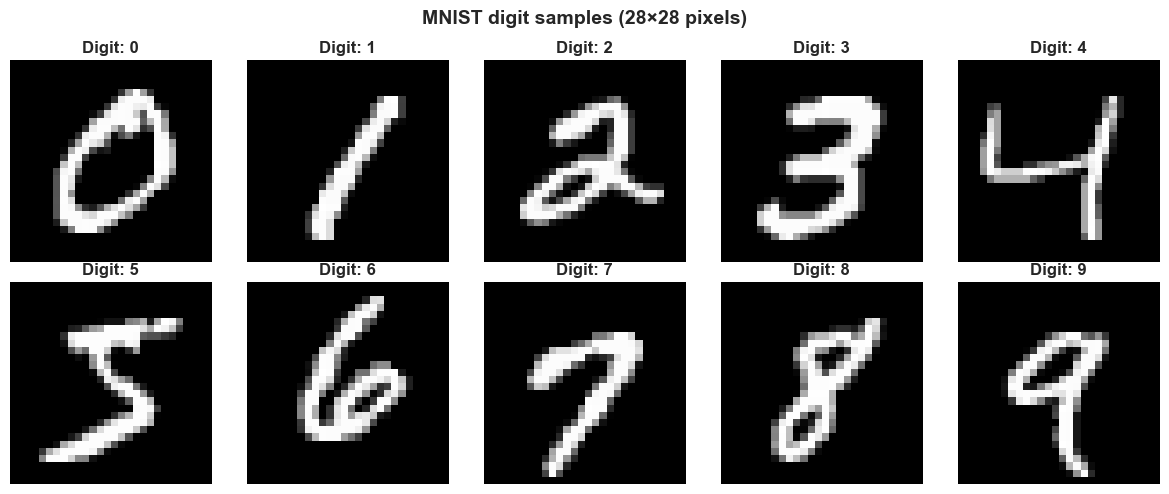

✅ Visualization successful!


In [4]:
# ============================================================================
# VISUALIZATION: Sample MNIST Images
# ============================================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

# For each class (0-9), display one example
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    image = X[idx].reshape(28, 28)
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f'Digit: {digit}', fontsize=12, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('MNIST digit samples (28×28 pixels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Visualization successful!')

---
## STEP 3: Data Preparation and Normalization

### Why normalize?
PCA is based on variance. If the features are not normalized, pixels with larger numeric scale could dominate the principal components. Standardization makes each feature comparable.


In [5]:
# ============================================================================
# TRAIN/TEST SPLIT
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✅ Train/Test split completed:')
print(f'   - Train: {X_train.shape[0]} images')
print(f'   - Test: {X_test.shape[0]} images')
print(f'   - Train ratio: {X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}')

✅ Train/Test split completed:
   - Train: 56000 images
   - Test: 14000 images
   - Train ratio: 80.0%


In [6]:
# ============================================================================
# FEATURE NORMALIZATION (StandardScaler)
# ============================================================================

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

print('📊 Statistics after normalization:')
print(f'   Train - Mean: {X_train_normalized.mean():.6f}, Std: {X_train_normalized.std():.6f}')
print(f'   Test  - Mean: {X_test_normalized.mean():.6f}, Std: {X_test_normalized.std():.6f}')
print(f'\n✅ Data normalized successfully!')
print(f'   - Train shape: {X_train_normalized.shape}')
print(f'   - Test shape: {X_test_normalized.shape}')

📊 Statistics after normalization:
   Train - Mean: 0.000000, Std: 0.956983
   Test  - Mean: 0.000728, Std: 3.017446

✅ Data normalized successfully!
   - Train shape: (56000, 784)
   - Test shape: (14000, 784)


### PCA interpretation
PCA keeps directions with the largest variance. That means the projection is designed for compression and visualization rather than class separation.


In [7]:
# ==============================================================================
# DATA NORMALIZATION (Min-Max Scaling)
# ==============================================================================
# We divide by 255.0 to keep pixel values between 0 and 1.
# This avoids amplifying background noise and preserves the true image structure.
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# ==============================================================================
# APPLY PCA
# ==============================================================================

# 2D PCA for visualization
pca_vis = PCA(n_components=2, random_state=42)
X_train_pca_vis = pca_vis.fit_transform(X_train_normalized)
X_test_pca_vis = pca_vis.transform(X_test_normalized)

# PCA with enough components to preserve 95% of the variance
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_pca_95 = pca_95.fit_transform(X_train_normalized)
X_test_pca_95 = pca_95.transform(X_test_normalized)

print('✅ PCA fitted successfully!')
print(f'\n📊 Dimensionality reduction:')
print(f'   Original: {X_train_normalized.shape[1]} dimensions')
print(f'   PCA (2 components): {X_train_pca_vis.shape[1]} dimensions')
print(f'   PCA (95% variance): {X_train_pca_95.shape[1]} dimensions')
print(f'\n   Explained variance with 2 components: {pca_vis.explained_variance_ratio_.sum()*100:.2f}%')
print(f'   Explained variance with 95% target: {pca_95.explained_variance_ratio_.sum()*100:.2f}%')

✅ PCA fitted successfully!

📊 Dimensionality reduction:
   Original: 784 dimensions
   PCA (2 components): 2 dimensions
   PCA (95% variance): 154 dimensions

   Explained variance with 2 components: 16.87%
   Explained variance with 95% target: 95.04%


In [8]:
# ============================================================================
# EXPLAINED VARIANCE ANALYSIS
# ============================================================================

explained_variance = pca_vis.explained_variance_ratio_
cumsum_variance = np.cumsum(pca_vis.explained_variance_ratio_)

print('📈 Explained variance by the first PCA components:')
print('-' * 60)
for i, (var, cum_var) in enumerate(zip(explained_variance, cumsum_variance), 1):
    bar = '█' * int(var * 60)
    print(f'Component {i}: {var:.4f} ({var*100:5.2f}%) | Cumulative: {cum_var:.4f} ({cum_var*100:6.2f}%) {bar}')

print('\n💡 Interpretation:')
print(f'   - The first component captures {explained_variance[0]*100:.2f}% of the variance')
print(f'   - The second component captures {explained_variance[1]*100:.2f}% of the variance')
print('   - PCA keeps the directions with the largest data spread, not the class separation')

📈 Explained variance by the first PCA components:
------------------------------------------------------------
Component 1: 0.0973 ( 9.73%) | Cumulative: 0.0973 (  9.73%) █████
Component 2: 0.0714 ( 7.14%) | Cumulative: 0.1687 ( 16.87%) ████

💡 Interpretation:
   - The first component captures 9.73% of the variance
   - The second component captures 7.14% of the variance
   - PCA keeps the directions with the largest data spread, not the class separation


---
## STEP 5: Visualize the 2D PCA Space

### What we expect
Unlike LDA, PCA is not trying to separate classes. It keeps variance, so the digits may overlap more. This is normal and is part of the lesson: PCA is excellent for compression, but not necessarily for class discrimination.


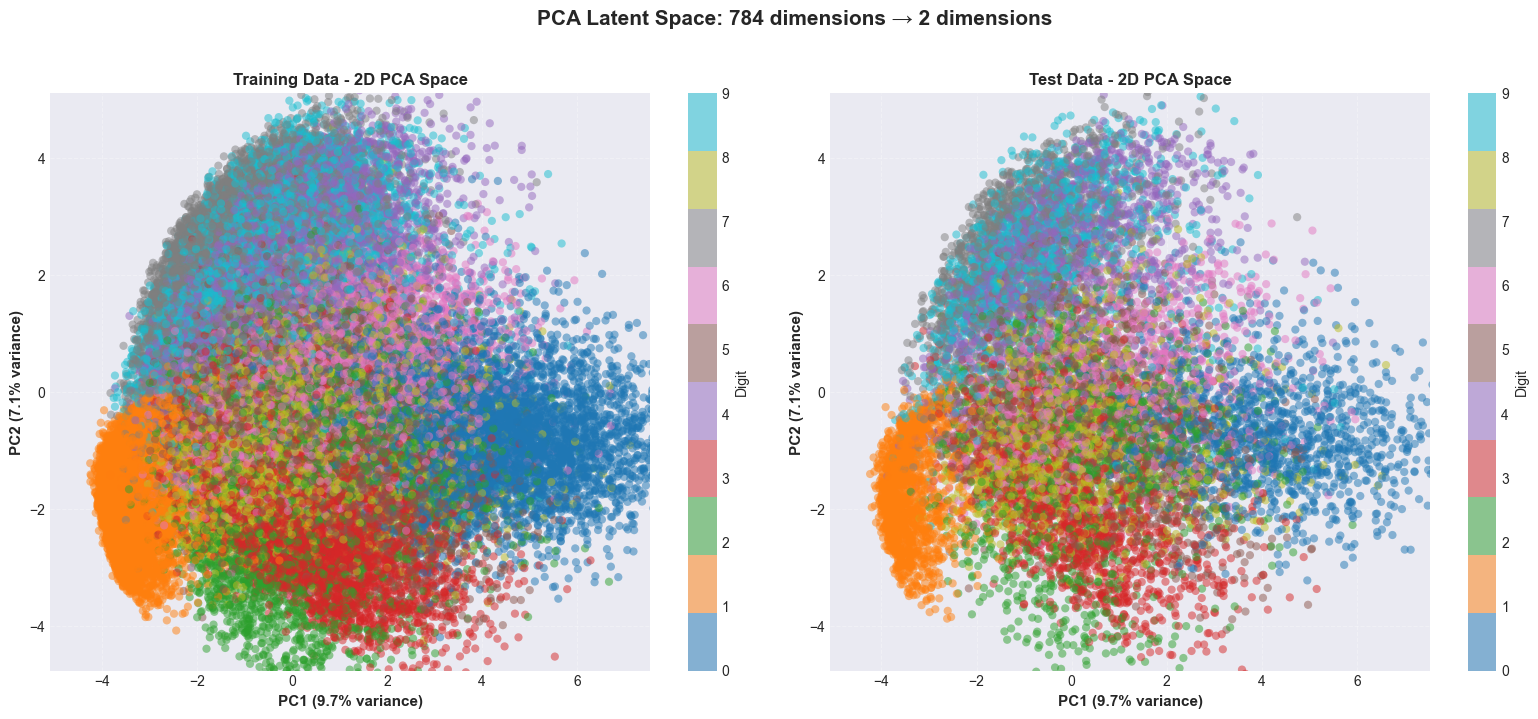

✅ PCA visualization successful!
✅ Figure exported for slide use: pca-story\assets\pca-latent-space-2d.png

💡 Observations:
   - PCA preserves variance, not class boundaries
   - Some digits overlap heavily in 2D, which is expected
   - The projection is still useful for compression and visualization


In [9]:
# ============================================================================
# VISUALIZATION: 2D PCA Projection
# ============================================================================

combined_2d = np.vstack([X_train_pca_vis, X_test_pca_vis])
x_min, x_max = np.percentile(combined_2d[:, 0], [1, 99])
y_min, y_max = np.percentile(combined_2d[:, 1], [1, 99])
pad_x = (x_max - x_min) * 0.12
pad_y = (y_max - y_min) * 0.12

plt.figure(figsize=(16, 7))

ax1 = plt.subplot(1, 2, 1)
scatter1 = ax1.scatter(
    X_train_pca_vis[:, 0],
    X_train_pca_vis[:, 1],
    c=y_train,
    cmap='tab10',
    s=35,
    alpha=0.5,
    edgecolors='none'
)
ax1.set_title('Training Data - 2D PCA Space', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlim(x_min - pad_x, x_max + pad_x)
ax1.set_ylim(y_min - pad_y, y_max + pad_y)
plt.colorbar(scatter1, ax=ax1, label='Digit', ticks=range(10))

ax2 = plt.subplot(1, 2, 2)
scatter2 = ax2.scatter(
    X_test_pca_vis[:, 0],
    X_test_pca_vis[:, 1],
    c=y_test,
    cmap='tab10',
    s=35,
    alpha=0.5,
    edgecolors='none'
)
ax2.set_title('Test Data - 2D PCA Space', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_xlim(x_min - pad_x, x_max + pad_x)
ax2.set_ylim(y_min - pad_y, y_max + pad_y)
plt.colorbar(scatter2, ax=ax2, label='Digit', ticks=range(10))

plt.suptitle('PCA Latent Space: 784 dimensions → 2 dimensions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the exact figure for the presentation slide
pca_story_assets = PROJECT_ROOT / 'pca-story' / 'assets'
pca_story_assets.mkdir(parents=True, exist_ok=True)
figure_path = pca_story_assets / 'pca-latent-space-2d.png'
plt.savefig(figure_path, dpi=180, bbox_inches='tight')

plt.show()

print('✅ PCA visualization successful!')
print(f'✅ Figure exported for slide use: {figure_path.relative_to(PROJECT_ROOT)}')
print('\n💡 Observations:')
print('   - PCA preserves variance, not class boundaries')
print('   - Some digits overlap heavily in 2D, which is expected')
print('   - The projection is still useful for compression and visualization')

---
## STEP 6: Classification on the Reduced PCA Space

### Why do this?
A simple classifier on the PCA-reduced space lets us measure whether the compression keeps enough information for digit recognition.


In [10]:
# ============================================================================
# TRAIN A SIMPLE CLASSIFIER ON PCA FEATURES
# ============================================================================

clf_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_pca.fit(X_train_pca_95, y_train)

y_pred_train_pca = clf_pca.predict(X_train_pca_95)
y_pred_test_pca = clf_pca.predict(X_test_pca_95)

accuracy_train_pca = accuracy_score(y_train, y_pred_train_pca)
accuracy_test_pca = accuracy_score(y_test, y_pred_test_pca)

print('✅ LogisticRegression classifier trained on PCA space!')
print('\n📊 Classification performance:')
print(f'   Train accuracy: {accuracy_train_pca*100:.2f}%')
print(f'   Test accuracy:  {accuracy_test_pca*100:.2f}%')
print('\n💡 Interpretation:')
print(f'   PCA reduced the feature space from 784 to {X_train_pca_95.shape[1]} dimensions while keeping most of the information.')

✅ LogisticRegression classifier trained on PCA space!

📊 Classification performance:
   Train accuracy: 92.80%
   Test accuracy:  92.08%

💡 Interpretation:
   PCA reduced the feature space from 784 to 154 dimensions while keeping most of the information.


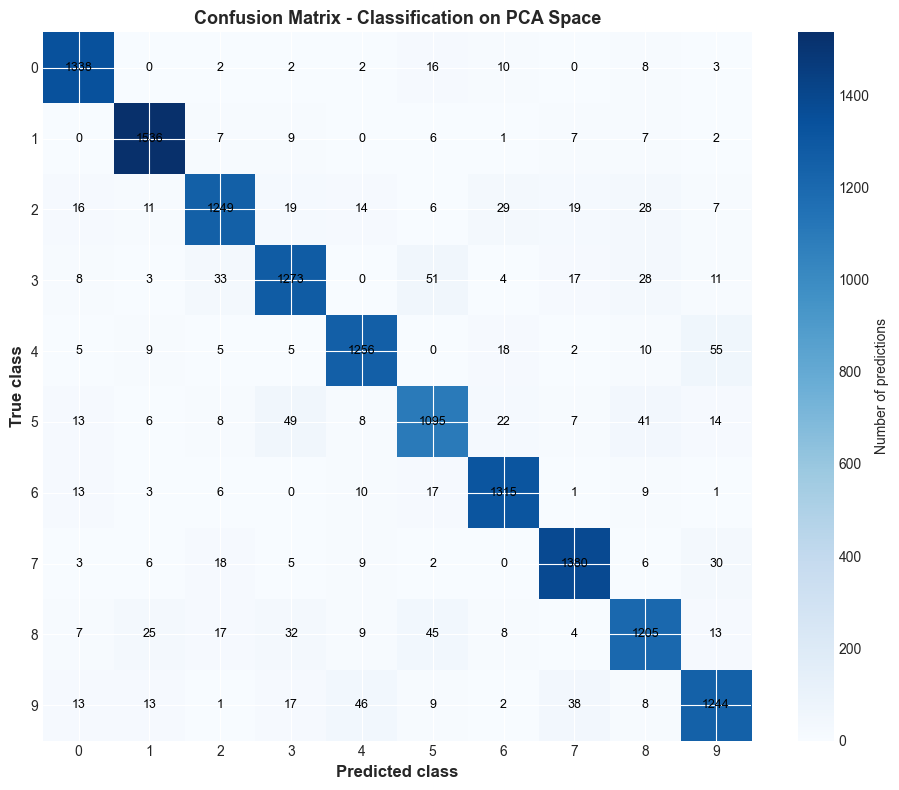

✅ Confusion matrix generated!

DETAILED CLASSIFICATION REPORT (PCA Test Data)
              precision    recall  f1-score   support

           0     0.9449    0.9689    0.9567      1381
           1     0.9529    0.9752    0.9639      1575
           2     0.9279    0.8934    0.9103      1398
           3     0.9022    0.8915    0.8968      1428
           4     0.9276    0.9201    0.9239      1365
           5     0.8781    0.8670    0.8725      1263
           6     0.9333    0.9564    0.9447      1375
           7     0.9356    0.9459    0.9407      1459
           8     0.8926    0.8828    0.8877      1365
           9     0.9014    0.8943    0.8979      1391

    accuracy                         0.9208     14000
   macro avg     0.9197    0.9195    0.9195     14000
weighted avg     0.9205    0.9208    0.9206     14000



In [11]:
# ============================================================================
# CONFUSION MATRIX AND REPORT
# ============================================================================

cm_pca = confusion_matrix(y_test, y_pred_test_pca)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_pca, cmap='Blues')
plt.colorbar(im, ax=ax, label='Number of predictions')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
for i in range(cm_pca.shape[0]):
    for j in range(cm_pca.shape[1]):
        ax.text(j, i, str(cm_pca[i, j]), ha='center', va='center', color='black', fontsize=9)

plt.xlabel('Predicted class', fontsize=12, fontweight='bold')
plt.ylabel('True class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Classification on PCA Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Confusion matrix generated!')

report_pca = classification_report(
    y_test,
    y_pred_test_pca,
    target_names=[str(i) for i in range(10)],
    digits=4
)

print('\n' + '='*80)
print('DETAILED CLASSIFICATION REPORT (PCA Test Data)')
print('='*80)
print(report_pca)
print('='*80)

---
## STEP 6b: Error Analysis

### Why this section?
The confusion matrix tells us where the classifier makes mistakes. A normalized view and a few representative misclassified images make the error pattern easier to understand.


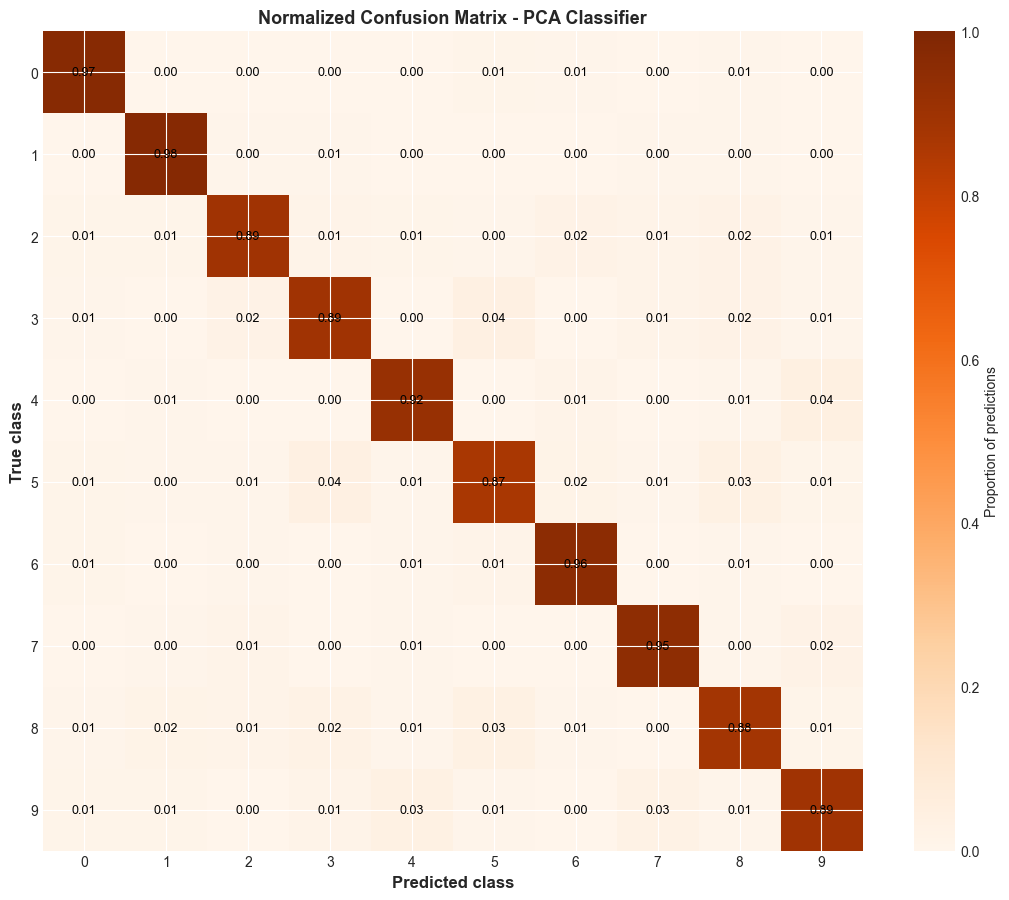


MOST FREQUENT CONFUSIONS
 True class  Predicted class  Errors  Rate (%)
          4                9      55  4.029304
          3                5      51  3.571429
          5                3      49  3.879652
          9                4      46  3.306973
          8                5      45  3.296703
          5                8      41  3.246239
          9                7      38  2.731848
          3                2      33  2.310924
          8                3      32  2.344322
          7                9      30  2.056203

Total misclassified samples: 1109


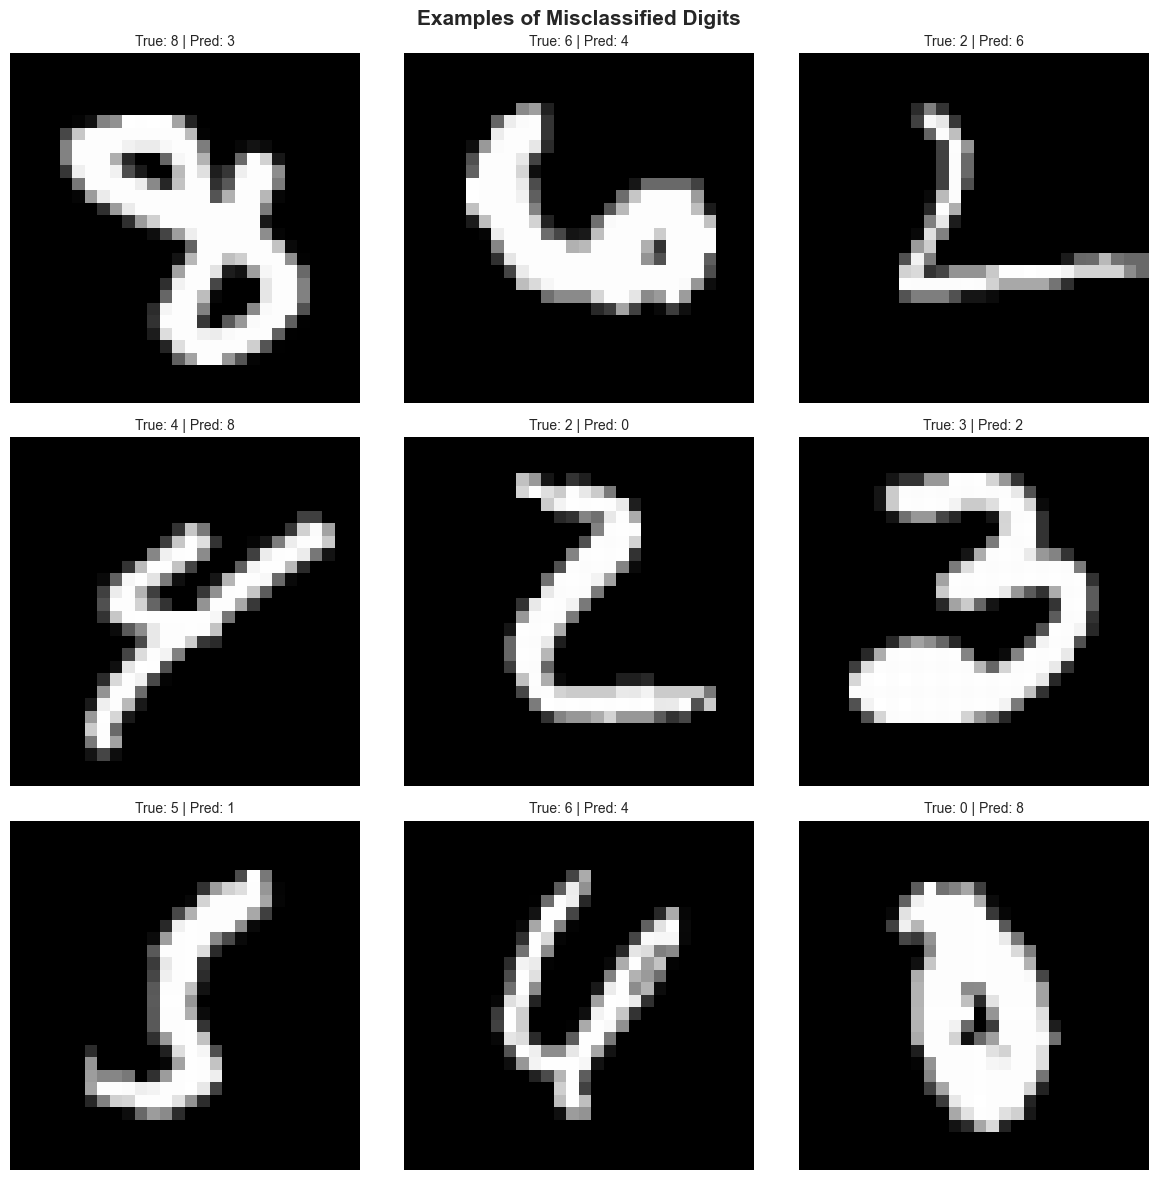


💡 Interpretation:
   - The normalized matrix shows which digits are the hardest to separate.
   - The table highlights the strongest confusion pairs.
   - The image examples show the actual digits that caused the errors.


In [12]:
# ============================================================================
# ERROR ANALYSIS ON THE PCA CLASSIFIER
# ============================================================================

# Normalized confusion matrix gives the percentage of predictions per true class
cm_pca_normalized = cm_pca.astype(float) / cm_pca.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_pca_normalized, cmap='Oranges', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Proportion of predictions')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
for i in range(cm_pca_normalized.shape[0]):
    for j in range(cm_pca_normalized.shape[1]):
        ax.text(j, i, f'{cm_pca_normalized[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)

plt.xlabel('Predicted class', fontsize=12, fontweight='bold')
plt.ylabel('True class', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix - PCA Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find the most frequent confusions, excluding the diagonal
error_pairs = []
for true_label in range(10):
    for predicted_label in range(10):
        if true_label != predicted_label and cm_pca[true_label, predicted_label] > 0:
            error_pairs.append({
                'True class': true_label,
                'Predicted class': predicted_label,
                'Errors': int(cm_pca[true_label, predicted_label]),
                'Rate (%)': float(cm_pca_normalized[true_label, predicted_label] * 100)
            })

errors_df = pd.DataFrame(error_pairs).sort_values(['Errors', 'Rate (%)'], ascending=False)

print('\n' + '='*80)
print('MOST FREQUENT CONFUSIONS')
print('='*80)
if len(errors_df) > 0:
    print(errors_df.head(10).to_string(index=False))
else:
    print('No misclassifications found in the test set.')

# Show a few misclassified images to make the errors concrete
misclassified_idx = np.where(y_pred_test_pca != y_test)[0]
print(f'\nTotal misclassified samples: {len(misclassified_idx)}')

if len(misclassified_idx) > 0:
    sample_count = min(9, len(misclassified_idx))
    sample_idx = misclassified_idx[:sample_count]

    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(sample_idx, 1):
        plt.subplot(3, 3, i)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f'True: {y_test[idx]} | Pred: {y_pred_test_pca[idx]}', fontsize=10)
        plt.axis('off')

    plt.suptitle('Examples of Misclassified Digits', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('\n💡 Interpretation:')
print('   - The normalized matrix shows which digits are the hardest to separate.')
print('   - The table highlights the strongest confusion pairs.')
print('   - The image examples show the actual digits that caused the errors.')

---
## STEP 7: Compare PCA with Direct Classification

This comparison shows the real effect of dimensionality reduction. We train the same classifier directly on the normalized 784-dimensional data and compare it to the PCA-reduced version.


In [13]:
# ============================================================================
# COMPARATIVE ANALYSIS: Original vs PCA
# ============================================================================

clf_direct = LogisticRegression(max_iter=1000, random_state=42)
clf_direct.fit(X_train_normalized, y_train)
y_pred_direct = clf_direct.predict(X_test_normalized)
accuracy_direct = accuracy_score(y_test, y_pred_direct)

print('\n' + '='*80)
print('COMPARISON: Direct classification vs PCA-space classification')
print('='*80)
print(f"\n{'Approach':<30} | {'Dimensions':<12} | {'Accuracy':<10} | {'Ratio'}")
print('-'*80)
print(f"{'Direct (784D)':<30} | {784:<12} | {accuracy_direct*100:>8.2f}% | 1.00x (reference)")
print(f"{f'PCA ({X_train_pca_95.shape[1]}D)':<30} | {X_train_pca_95.shape[1]:<12} | {accuracy_test_pca*100:>8.2f}% | {accuracy_test_pca/accuracy_direct:.2f}x")
print('-'*80)
print(f"Dimensionality reduction: {784} → {X_train_pca_95.shape[1]} = {(1 - X_train_pca_95.shape[1]/784)*100:.1f}% fewer dimensions")
print(f"Accuracy loss: {(1 - accuracy_test_pca/accuracy_direct)*100:.2f}%")
print('\n✅ Conclusion: PCA compresses the data strongly while preserving much of the useful signal.')


COMPARISON: Direct classification vs PCA-space classification

Approach                       | Dimensions   | Accuracy   | Ratio
--------------------------------------------------------------------------------
Direct (784D)                  | 784          |    92.16% | 1.00x (reference)
PCA (154D)                     | 154          |    92.08% | 1.00x
--------------------------------------------------------------------------------
Dimensionality reduction: 784 → 154 = 80.4% fewer dimensions
Accuracy loss: 0.09%

✅ Conclusion: PCA compresses the data strongly while preserving much of the useful signal.


### Summary
- PCA is an unsupervised dimensionality reduction method.
- It preserves the directions with the highest variance.
- It can compress MNIST from 784 dimensions to a much smaller space while keeping most of the useful information.
- It is useful for visualization, compression, denoising, and faster downstream learning.

### Practical note
If the goal is representation and compression, PCA is a natural choice. If the goal is classification, a supervised method can sometimes perform better because it can use labels directly.

### Thank you!
*This notebook shows how PCA can be used on MNIST with a clear step-by-step explanation.*